In [113]:
from src.helpers.model_matrix import build_model_matrix_from_wrds

In [114]:
from src.helpers.model_matrix import align_and_fill_dates_across_tickers

In [115]:

import warnings

import numpy as np
import pandas as pd
import pandas_ta as ta
import yfinance as yf


def _flatten_price_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


def _as_series(obj: pd.Series | pd.DataFrame, name: str) -> pd.Series:
    if isinstance(obj, pd.DataFrame):
        if name in obj.columns:
            return obj[name]
        return obj.iloc[:, 0]
    return obj.rename(name) if obj.name != name else obj


def prepare_daily_indicator_dataset(
    ticker: str,
    start: str | None = '2000-01-01',
    end: str | None = None,
    horizon: int = 1,
    dropna: bool = True,
    min_obs: int = 60,
) -> pd.DataFrame:
    daily = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
    if daily.empty:
        raise ValueError('No price history returned by yfinance.')
    daily = _flatten_price_columns(daily)
    daily = daily[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].dropna()
    daily.index = daily.index.tz_localize(None)
    daily = daily.sort_index()
    if len(daily) < max(min_obs, 35):
        raise ValueError('Not enough observations to compute indicators.')

    high = daily['High']
    low = daily['Low']
    close = daily['Close']
    adj_close = daily['Adj Close']
    volume = daily['Volume'].astype(float)

    log_rets = np.log(adj_close).diff()

    frame = pd.DataFrame(index=daily.index)
    frame['date'] = daily.index
    frame['adjclose_lead'] = log_rets.shift(-horizon)
    frame['direction_lead'] = np.where(frame['adjclose_lead'] > 0, 1, 0)
    frame.loc[frame['adjclose_lead'].isna(), 'direction_lead'] = np.nan
    frame['adjclose_lag0'] = log_rets
    frame['adjclose_lag1'] = log_rets.shift(1)
    frame['adjclose_lag2'] = log_rets.shift(2)
    frame['adjclose_lag3'] = log_rets.shift(3)

    # pandas_ta indicators
    frame['atr_14'] = ta.atr(high=high, low=low, close=close, length=14)

    adx = ta.adx(high=high, low=low, close=close, length=14)
    if adx is not None and 'ADX_14' in adx:
        frame['adx_14'] = adx['ADX_14']

    bb = ta.bbands(close=close, length=20, std=2)
    if isinstance(bb, pd.DataFrame):
        percent_col = next((col for col in bb.columns if col.startswith('BBP_')), None)
        if percent_col is not None:
            frame['bb_percent_20_2'] = bb[percent_col]

    macd = ta.macd(close=close, fast=12, slow=26, signal=9)
    if macd is not None and 'MACD_12_26_9' in macd:
        frame['macd_12_26_9'] = macd['MACD_12_26_9']

    mfi = ta.mfi(high=high, low=low, close=close, volume=volume, length=14)
    frame['mfi_14'] = _as_series(mfi, 'mfi_14')

    psar = ta.psar(high=high, low=low, close=close, step=0.02, max=0.2)
    if psar is not None and 'PSARaf_0.02_0.2' in psar:
        frame['psar_acc'] = psar['PSARaf_0.02_0.2']

    cmf = ta.cmf(high=high, low=low, close=close, volume=volume, length=20)
    frame['cmf_20'] = _as_series(cmf, 'cmf_20')

    eom = ta.eom(high=high, low=low, close=close, volume=volume, length=14)
    if eom is not None:
        frame['eom_14'] = _as_series(eom, 'eom_14')

    frame['rsi_14'] = _as_series(ta.rsi(close=close, length=14), 'rsi_14')
    frame['variance_21'] = _as_series(ta.variance(close=close, length=21), 'variance_21')

    stoch = ta.stoch(high=high, low=low, close=close, k=14, d=3, smooth_k=3)
    if stoch is not None and 'STOCHk_14_3_3' in stoch:
        frame['stoch_k_14_3_3'] = stoch['STOCHk_14_3_3']

    frame['skew_63'] = _as_series(ta.skew(close=close, length=63), 'skew_63')
    frame['kurtosis_63'] = _as_series(ta.kurtosis(close=close, length=63), 'kurtosis_63')

    aroon = ta.aroon(high=high, low=low, length=25)
    if aroon is not None and 'AROONOSC_25' in aroon:
        frame['aroon_osc_25'] = aroon['AROONOSC_25']

    frame = frame.dropna(axis=1, how='all')

    essential_cols = [
        'adjclose_lead',
        'direction_lead',
        'adjclose_lag0',
        'adjclose_lag1',
        'adjclose_lag2',
        'adjclose_lag3',
    ]
    essential_cols = [col for col in essential_cols if col in frame.columns]

    warmup = 63
    if len(frame) > warmup:
        frame = frame.iloc[warmup:].copy()

    if essential_cols:
        frame = frame.dropna(subset=essential_cols)

    indicator_cols = [col for col in frame.columns if col not in {'date'}]

    if indicator_cols:
        frame[indicator_cols] = (
            frame[indicator_cols]
            .ffill()
            .bfill()
            .fillna(0)
        )

    if dropna:
        frame = frame.dropna().reset_index(drop=True)
    else:
        frame = frame.reset_index(drop=True)

    if len(frame) < min_obs:
        raise ValueError('Not enough post-processing observations.')
    return frame


def prepare_daily_indicator_panel(
    tickers: list[str],
    start: str | None = '2000-01-01',
    end: str | None = None,
    horizon: int = 1,
    dropna: bool = True,
    min_obs: int = 60,
    warmup_buffer_days: int = 120,
) -> pd.DataFrame:
    frames = []
    requested_start = pd.to_datetime(start) if start is not None else None
    buffered_start = None
    if requested_start is not None:
        buffered_start = (requested_start - pd.Timedelta(days=warmup_buffer_days)).strftime('%Y-%m-%d')

    for ticker in tickers:
        data_start = buffered_start if buffered_start is not None else start
        try:
            frame = prepare_daily_indicator_dataset(
                ticker=ticker,
                start=data_start,
                end=end,
                horizon=horizon,
                dropna=dropna,
                min_obs=min_obs,
            )
        except ValueError as exc:
            warnings.warn(f'Skipping {ticker}: {exc}')
            continue
        frame['ticker'] = ticker
        frames.append(frame)
    if not frames:
        raise ValueError('No data downloaded for the provided tickers.')
    panel = (
        pd.concat(frames, ignore_index=True)
        .assign(date=lambda df_: pd.to_datetime(df_['date']))
        .sort_values(['ticker', 'date'])
        .set_index(['ticker', 'date'])
    )
    if requested_start is not None:
        panel = panel[panel.index.get_level_values('date') >= requested_start]
    return panel


# Build a multi-ticker daily panel ready for modelling.
daily_indicator_panel = prepare_daily_indicator_panel(
    tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META'],
    start='2015-01-01',
    end='2019-12-31',
    horizon=1,
    dropna=True,
    min_obs=120,
)

daily_indicator_panel


adjclose_lead  direction_lead  adjclose_lag0  \
ticker date                                                       
AAPL   2015-01-02      -0.028576             0.0      -0.009558   
       2015-01-05       0.000094             1.0      -0.028576   
       2015-01-06       0.013925             1.0       0.000094   
       2015-01-07       0.037703             1.0       0.013925   
       2015-01-08       0.001072             1.0       0.037703   
...                          ...             ...            ...   
MSFT   2019-12-20       0.000000             0.0       0.010859   
       2019-12-23      -0.000190             0.0       0.000000   
       2019-12-24       0.008163             1.0      -0.000190   
       2019-12-26       0.001826             1.0       0.008163   
       2019-12-27      -0.008656             0.0       0.001826   

                   adjclose_lag1  adjclose_lag2  adjclose_lag3    atr_14  \
ticker date                                                                
AAPL   2015-01-02      -0.019202      -0.012278      -0.000702  0.617830   
       2015-01-05      -0.009558      -0.019202      -0.012278  0.643699   
       2015-01-06      -0.028576      -0.009558      -0.019202  0.647721   
       2015-01-07       0.000094      -0.028576      -0.009558  0.636098   
       2015-01-08       0.013925       0.000094      -0.028576  0.669234   
...                          ...            ...            ...       ...   
MSFT   2019-12-20       0.008643      -0.002071      -0.005415  1.765100   
       2019-12-23       0.010859       0.008643      -0.002071  1.699735   
       2019-12-24       0.000000       0.010859       0.008643  1.620469   
       2019-12-26      -0.000190       0.000000       0.010859  1.601150   
       2019-12-27       0.008163      -0.000190       0.000000  1.581782   

                      adx_14  bb_percent_20_2  macd_12_26_9     mfi_14  \
ticker date                                                              
AAPL   2015-01-02  23.679731         0.217337     -0.042373  47.259896   
       2015-01-05  24.887027        -0.041532     -0.148512  46.823469   
       2015-01-06  26.194960         0.024853     -0.229778  47.032679   
       2015-01-07  26.952096         0.208044     -0.261114  54.596425   
       2015-01-08  25.719537         0.633542     -0.200125  55.089679   
...                      ...              ...           ...        ...   
MSFT   2019-12-20  29.299369         1.055666      2.424918  72.732979   
       2019-12-23  30.162920         0.979143      2.524014  79.507484   
       2019-12-24  30.834797         0.915195      2.570497  76.067640   
       2019-12-26  31.830477         0.960846      2.680527  75.877868   
       2019-12-27  33.028788         0.922836      2.759320  76.099036   

                   psar_acc    cmf_20    eom_14     rsi_14  variance_21  \
ticker date                                                               
AAPL   2015-01-02      0.02 -0.272452 -0.042148  42.529447     0.357246   
       2015-01-05      0.04 -0.263783 -0.047034  36.045978     0.400316   
       2015-01-06      0.06 -0.226200 -0.036529  36.080056     0.427814   
       2015-01-07      0.06 -0.185031 -0.025124  41.113935     0.408977   
       2015-01-08      0.06 -0.190761 -0.006585  52.344022     0.404609   
...                     ...       ...       ...        ...          ...   
MSFT   2019-12-20      0.12  0.224972  2.705781  75.142622     5.609612   
       2019-12-23      0.12  0.196091  4.489405  75.142622     6.451325   
       2019-12-24      0.12  0.156752  3.700941  74.942281     7.017769   
       2019-12-26      0.14  0.174737  4.055680  77.696078     8.378932   
       2019-12-27      0.16  0.155807  3.663608  78.274141     9.787374   

                   stoch_k_14_3_3   skew_63  kurtosis_63  aroon_osc_25  
ticker date                                                             
AAPL   2015-01-02       52.454745 -0.480466    -0.758468         -56.0  


In [116]:

import warnings

import numpy as np
import pandas as pd
import pandas_ta as ta
import yfinance as yf


def _flatten_price_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


def _as_series(obj: pd.Series | pd.DataFrame, name: str) -> pd.Series:
    if isinstance(obj, pd.DataFrame):
        if name in obj.columns:
            return obj[name]
        return obj.iloc[:, 0]
    return obj.rename(name) if obj.name != name else obj


def prepare_daily_indicator_dataset(
    ticker: str,
    start: str | None = '2000-01-01',
    end: str | None = None,
    horizon: int = 1,
    dropna: bool = True,
    min_obs: int = 60,
) -> pd.DataFrame:
    daily = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
    if daily.empty:
        raise ValueError('No price history returned by yfinance.')
    daily = _flatten_price_columns(daily)
    daily = daily[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].dropna()
    daily.index = daily.index.tz_localize(None)
    daily = daily.sort_index()
    if len(daily) < max(min_obs, 35):
        raise ValueError('Not enough observations to compute indicators.')

    high = daily['High']
    low = daily['Low']
    close = daily['Close']
    adj_close = daily['Adj Close']
    volume = daily['Volume'].astype(float)

    log_rets = np.log(adj_close).diff()

    frame = pd.DataFrame(index=daily.index)
    frame['date'] = daily.index
    frame['adjclose_lead'] = log_rets.shift(-horizon)
    frame['direction_lead'] = np.where(frame['adjclose_lead'] > 0, 1, 0)
    frame.loc[frame['adjclose_lead'].isna(), 'direction_lead'] = np.nan
    frame['adjclose_lag0'] = log_rets
    frame['adjclose_lag1'] = log_rets.shift(1)
    frame['adjclose_lag2'] = log_rets.shift(2)
    frame['adjclose_lag3'] = log_rets.shift(3)

    # pandas_ta indicators
    frame['atr_14'] = ta.atr(high=high, low=low, close=close, length=14)

    adx = ta.adx(high=high, low=low, close=close, length=14)
    if adx is not None and 'ADX_14' in adx:
        frame['adx_14'] = adx['ADX_14']

    bb = ta.bbands(close=close, length=20, std=2)
    if isinstance(bb, pd.DataFrame):
        percent_col = next((col for col in bb.columns if col.startswith('BBP_')), None)
        if percent_col is not None:
            frame['bb_percent_20_2'] = bb[percent_col]

    macd = ta.macd(close=close, fast=12, slow=26, signal=9)
    if macd is not None and 'MACD_12_26_9' in macd:
        frame['macd_12_26_9'] = macd['MACD_12_26_9']

    mfi = ta.mfi(high=high, low=low, close=close, volume=volume, length=14)
    frame['mfi_14'] = _as_series(mfi, 'mfi_14')

    psar = ta.psar(high=high, low=low, close=close, step=0.02, max=0.2)
    if psar is not None and 'PSARaf_0.02_0.2' in psar:
        frame['psar_acc'] = psar['PSARaf_0.02_0.2']

    cmf = ta.cmf(high=high, low=low, close=close, volume=volume, length=20)
    frame['cmf_20'] = _as_series(cmf, 'cmf_20')

    eom = ta.eom(high=high, low=low, close=close, volume=volume, length=14)
    if eom is not None:
        frame['eom_14'] = _as_series(eom, 'eom_14')

    frame['rsi_14'] = _as_series(ta.rsi(close=close, length=14), 'rsi_14')
    frame['variance_21'] = _as_series(ta.variance(close=close, length=21), 'variance_21')

    stoch = ta.stoch(high=high, low=low, close=close, k=14, d=3, smooth_k=3)
    if stoch is not None and 'STOCHk_14_3_3' in stoch:
        frame['stoch_k_14_3_3'] = stoch['STOCHk_14_3_3']

    frame['skew_63'] = _as_series(ta.skew(close=close, length=63), 'skew_63')
    frame['kurtosis_63'] = _as_series(ta.kurtosis(close=close, length=63), 'kurtosis_63')

    aroon = ta.aroon(high=high, low=low, length=25)
    if aroon is not None and 'AROONOSC_25' in aroon:
        frame['aroon_osc_25'] = aroon['AROONOSC_25']

    frame = frame.dropna(axis=1, how='all')

    essential_cols = [
        'adjclose_lead',
        'direction_lead',
        'adjclose_lag0',
        'adjclose_lag1',
        'adjclose_lag2',
        'adjclose_lag3',
    ]
    essential_cols = [col for col in essential_cols if col in frame.columns]

    warmup = 63
    if len(frame) > warmup:
        frame = frame.iloc[warmup:].copy()

    if essential_cols:
        frame = frame.dropna(subset=essential_cols)

    indicator_cols = [col for col in frame.columns if col not in {'date'}]

    if indicator_cols:
        frame[indicator_cols] = (
            frame[indicator_cols]
            .ffill()
            .bfill()
            .fillna(0)
        )

    if dropna:
        frame = frame.dropna().reset_index(drop=True)
    else:
        frame = frame.reset_index(drop=True)

    if len(frame) < min_obs:
        raise ValueError('Not enough post-processing observations.')
    return frame


def prepare_daily_indicator_panel(
    tickers: list[str],
    start: str | None = '2000-01-01',
    end: str | None = None,
    horizon: int = 1,
    dropna: bool = True,
    min_obs: int = 60,
    warmup_buffer_days: int = 120,
) -> pd.DataFrame:
    frames = []
    requested_start = pd.to_datetime(start) if start is not None else None
    buffered_start = None
    if requested_start is not None:
        buffered_start = (requested_start - pd.Timedelta(days=warmup_buffer_days)).strftime('%Y-%m-%d')

    for ticker in tickers:
        data_start = buffered_start if buffered_start is not None else start
        try:
            frame = prepare_daily_indicator_dataset(
                ticker=ticker,
                start=data_start,
                end=end,
                horizon=horizon,
                dropna=dropna,
                min_obs=min_obs,
            )
        except ValueError as exc:
            warnings.warn(f'Skipping {ticker}: {exc}')
            continue
        frame['ticker'] = ticker
        frames.append(frame)
    if not frames:
        raise ValueError('No data downloaded for the provided tickers.')
    panel = (
        pd.concat(frames, ignore_index=True)
        .assign(date=lambda df_: pd.to_datetime(df_['date']))
        .sort_values(['ticker', 'date'])
        .set_index(['ticker', 'date'])
    )
    if requested_start is not None:
        panel = panel[panel.index.get_level_values('date') >= requested_start]
    return panel


# Build a multi-ticker daily panel ready for modelling.
daily_indicator_panel = prepare_daily_indicator_panel(
    tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META'],
    start='2015-01-01',
    end='2019-12-31',
    horizon=1,
    dropna=True,
    min_obs=120,
)

daily_indicator_panel


adjclose_lead  direction_lead  adjclose_lag0  \
ticker date                                                       
AAPL   2015-01-02      -0.028576             0.0      -0.009558   
       2015-01-05       0.000094             1.0      -0.028576   
       2015-01-06       0.013925             1.0       0.000094   
       2015-01-07       0.037703             1.0       0.013925   
       2015-01-08       0.001072             1.0       0.037703   
...                          ...             ...            ...   
MSFT   2019-12-20       0.000000             0.0       0.010859   
       2019-12-23      -0.000190             0.0       0.000000   
       2019-12-24       0.008163             1.0      -0.000190   
       2019-12-26       0.001826             1.0       0.008163   
       2019-12-27      -0.008656             0.0       0.001826   

                   adjclose_lag1  adjclose_lag2  adjclose_lag3    atr_14  \
ticker date                                                                
AAPL   2015-01-02      -0.019202      -0.012278      -0.000702  0.617830   
       2015-01-05      -0.009558      -0.019202      -0.012278  0.643699   
       2015-01-06      -0.028576      -0.009558      -0.019202  0.647721   
       2015-01-07       0.000094      -0.028576      -0.009558  0.636098   
       2015-01-08       0.013925       0.000094      -0.028576  0.669234   
...                          ...            ...            ...       ...   
MSFT   2019-12-20       0.008643      -0.002071      -0.005415  1.765100   
       2019-12-23       0.010859       0.008643      -0.002071  1.699735   
       2019-12-24       0.000000       0.010859       0.008643  1.620469   
       2019-12-26      -0.000190       0.000000       0.010859  1.601150   
       2019-12-27       0.008163      -0.000190       0.000000  1.581782   

                      adx_14  bb_percent_20_2  macd_12_26_9     mfi_14  \
ticker date                                                              
AAPL   2015-01-02  23.679731         0.217337     -0.042373  47.259896   
       2015-01-05  24.887027        -0.041532     -0.148512  46.823469   
       2015-01-06  26.194960         0.024853     -0.229778  47.032679   
       2015-01-07  26.952096         0.208044     -0.261114  54.596425   
       2015-01-08  25.719537         0.633542     -0.200125  55.089679   
...                      ...              ...           ...        ...   
MSFT   2019-12-20  29.299369         1.055666      2.424918  72.732979   
       2019-12-23  30.162920         0.979143      2.524014  79.507484   
       2019-12-24  30.834797         0.915195      2.570497  76.067640   
       2019-12-26  31.830477         0.960846      2.680527  75.877868   
       2019-12-27  33.028788         0.922836      2.759320  76.099036   

                   psar_acc    cmf_20    eom_14     rsi_14  variance_21  \
ticker date                                                               
AAPL   2015-01-02      0.02 -0.272452 -0.042148  42.529447     0.357246   
       2015-01-05      0.04 -0.263783 -0.047034  36.045978     0.400316   
       2015-01-06      0.06 -0.226200 -0.036529  36.080056     0.427814   
       2015-01-07      0.06 -0.185031 -0.025124  41.113935     0.408977   
       2015-01-08      0.06 -0.190761 -0.006585  52.344022     0.404609   
...                     ...       ...       ...        ...          ...   
MSFT   2019-12-20      0.12  0.224972  2.705781  75.142622     5.609612   
       2019-12-23      0.12  0.196091  4.489405  75.142622     6.451325   
       2019-12-24      0.12  0.156752  3.700941  74.942281     7.017769   
       2019-12-26      0.14  0.174737  4.055680  77.696078     8.378932   
       2019-12-27      0.16  0.155807  3.663608  78.274141     9.787374   

                   stoch_k_14_3_3   skew_63  kurtosis_63  aroon_osc_25  
ticker date                                                             
AAPL   2015-01-02       52.454745 -0.480466    -0.758468         -56.0  


In [117]:
def _flatten_price_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


def prepare_weekly_classification_dataset(ticker='^GSPC', start='2000-01-01', end=None):
    """Download daily prices and engineer lagged weekly features for a binary direction label."""
    raw = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
    raw = _flatten_price_columns(raw)
    raw = raw[['Adj Close', 'Close', 'High', 'Low', 'Volume']].dropna()
    raw.index = raw.index.tz_localize(None)

    raw['log_return'] = np.log(raw['Adj Close']).diff()
    raw['simple_return'] = raw['Adj Close'].pct_change()

    weekly_index = raw.resample('W-FRI').last().index
    weekly = pd.DataFrame(index=weekly_index)
    weekly['adj_close'] = raw['Adj Close'].resample('W-FRI').last()
    weekly['high'] = raw['High'].resample('W-FRI').max()
    weekly['low'] = raw['Low'].resample('W-FRI').min()
    weekly['volume'] = raw['Volume'].resample('W-FRI').sum()
    weekly['log_return'] = raw['log_return'].resample('W-FRI').sum()
    weekly['simple_return'] = weekly['adj_close'].pct_change()

    weekly['ret_lag1'] = weekly['log_return'].shift(1)
    weekly['ret_lag2'] = weekly['log_return'].shift(2)
    weekly['ret_lag3'] = weekly['log_return'].shift(3)
    weekly['momentum_4w'] = weekly['log_return'].rolling(4).sum()
    weekly['momentum_12w'] = weekly['log_return'].rolling(12).sum()
    weekly['sma_ratio_4'] = weekly['adj_close'] / weekly['adj_close'].rolling(4).mean() - 1
    weekly['sma_ratio_12'] = weekly['adj_close'] / weekly['adj_close'].rolling(12).mean() - 1

    daily_vol = raw['log_return'].rolling(21 * 3).std() * np.sqrt(252)
    weekly['vol_3m'] = daily_vol.resample('W-FRI').last()

    weekly['volume_z'] = (weekly['volume'] - weekly['volume'].rolling(12).mean()) / weekly['volume'].rolling(12).std()
    weekly['volume_z'] = weekly['volume_z'].replace([np.inf, -np.inf], np.nan)
    weekly['range_frac'] = (weekly['high'] - weekly['low']) / weekly['adj_close']

    weekly['future_simple_return'] = weekly['simple_return'].shift(-1)
    weekly['direction_lead'] = (weekly['future_simple_return'] > 0).astype(int)

    weekly.index.name = 'date'
    weekly = weekly.dropna().reset_index()
    return weekly


def confusion_frame(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return pd.DataFrame(cm, index=['Actual Down', 'Actual Up'], columns=['Pred Down', 'Pred Up'])

## Chapter 4 Logistic Regression Baseline (Daily Data)

In [118]:

TRAIN_END = pd.Timestamp('2018-12-31')
TEST_START = pd.Timestamp('2019-01-01')

print(f"Train ends: {TRAIN_END.date()} | Test starts: {TEST_START.date()}")


Train ends: 2018-12-31 | Test starts: 2019-01-01


### Prepare Feature Matrix and Train/Test Split

In [119]:

panel = daily_indicator_panel.sort_index(level=['date', 'ticker'])

feature_cols = [
    'adjclose_lag0', 'adjclose_lag1', 'adjclose_lag2', 'adjclose_lag3',
    'atr_14',
    'adx_14',
    'bb_percent_20_2',
    'macd_12_26_9',
    'mfi_14',
    'psar_acc',
    'cmf_20',
    'eom_14',
    'rsi_14',
    'variance_21',
    'stoch_k_14_3_3',
    'skew_63',
    'kurtosis_63',
    'aroon_osc_25',
]

available_cols = [c for c in feature_cols if c in panel.columns]
missing_cols = sorted(set(feature_cols) - set(available_cols))
if missing_cols:
    warnings.warn(f'Missing expected columns: {missing_cols}')

panel_work = panel[available_cols + ['adjclose_lead', 'direction_lead']].dropna().copy()

log_ret = panel['adjclose_lead']
simple_ret = np.expm1(log_ret)

train_mask = panel_work.index.get_level_values('date') <= TRAIN_END
test_mask = panel_work.index.get_level_values('date') >= TEST_START

train = panel_work.loc[train_mask]
test = panel_work.loc[test_mask]

X_train, y_train = train[available_cols], train['direction_lead'].astype(int)
X_test, y_test = test[available_cols], test['direction_lead'].astype(int)

simple_ret_train = simple_ret.loc[train.index]
simple_ret_test = simple_ret.loc[test.index]

print(f"Train observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")
print(f"Features used: {len(available_cols)}")


Train observations: 5,030
Test observations: 1,250
Features used: 18


### Fit Logistic Regression

In [120]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logit_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
    )),
])

logit_pipeline.fit(X_train, y_train)

train_accuracy = accuracy_score(y_train, logit_pipeline.predict(X_train))
test_accuracy = accuracy_score(y_test, logit_pipeline.predict(X_test))
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())

pd.DataFrame({
    'Metric': ['Train accuracy', 'Test accuracy', 'Test baseline (majority class)'],
    'Value': [train_accuracy, test_accuracy, baseline_accuracy],
})


,Metric,Value
0,Train accuracy,0.527833
1,Test accuracy,0.511200
2,Test baseline (majority class),0.551200


### Coefficient Inspection

In [121]:

coef_series = pd.Series(
    logit_pipeline.named_steps['logit'].coef_.ravel(),
    index=X_train.columns
)
coef_table = (
    pd.DataFrame({'coefficient': coef_series, 'abs_coef': coef_series.abs()})
    .sort_values('abs_coef', ascending=False)
)
coef_table


,coefficient,abs_coef
rsi_14,-0.132914,0.132914
bb_percent_20_2,0.126792,0.126792
eom_14,-0.096196,0.096196
stoch_k_14_3_3,-0.095018,0.095018
mfi_14,-0.091471,0.091471
macd_12_26_9,0.091235,0.091235
psar_acc,0.071562,0.071562
aroon_osc_25,0.048522,0.048522
kurtosis_63,0.044104,0.044104
cmf_20,0.041210,0.041210


### Test-Set Metrics

In [122]:

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

proba_test = logit_pipeline.predict_proba(X_test)[:, 1]
preds_test = (proba_test >= 0.5).astype(int)

metrics = {
    'accuracy': accuracy_score(y_test, preds_test),
    'precision': precision_score(y_test, preds_test),
    'recall': recall_score(y_test, preds_test),
    'f1': f1_score(y_test, preds_test),
    'roc_auc': roc_auc_score(y_test, proba_test),
}
metrics


{'accuracy': 0.5112,
 'precision': 0.5605590062111802,
 'recall': 0.5239477503628447,
 'f1': 0.5416354088522131,
 'roc_auc': 0.5020606474546542}

In [123]:

conf_matrix = confusion_matrix(y_test, preds_test)
pd.DataFrame(conf_matrix, index=['Actual Sell (0)', 'Actual Buy (1)'], columns=['Pred Sell (0)', 'Pred Buy (1)'])


,Pred Sell (0),Pred Buy (1)
Actual Sell (0),278,283
Actual Buy (1),328,361


### Probability Distribution (Test Set)

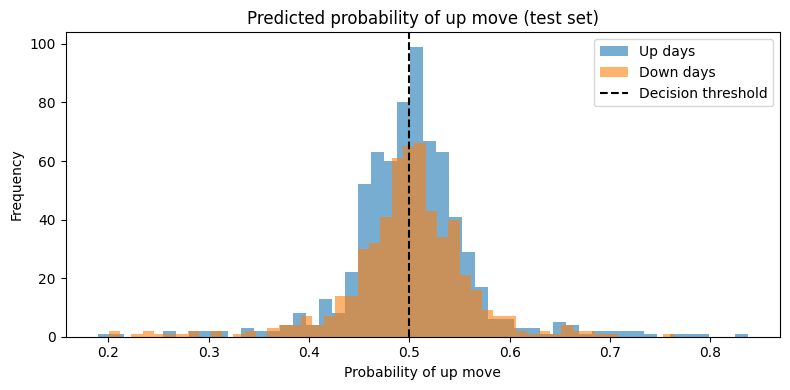

In [124]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(proba_test[y_test == 1], bins=50, alpha=0.6, label='Up days')
plt.hist(proba_test[y_test == 0], bins=50, alpha=0.6, label='Down days')
plt.axvline(0.5, color='k', linestyle='--', label='Decision threshold')
plt.title('Predicted probability of up move (test set)')
plt.xlabel('Probability of up move')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()
